<a href="https://colab.research.google.com/github/ravichas/bifx-546/blob/main/Notebooks/Chapter16_LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 16: Logistic Regression

## 💬 Opening Quote

> *"A lot of people say there's a fine line between genius and insanity.  
> I don't think there's a fine line, I actually think there's a yawning gulf."*  
> — **Bill Bailey**

This chapter is about **logistic regression**: a classification method that is conceptually simple, mathematically principled, and—once you understand it—not magic at all.

🎓 Course Context

Prepared for BIFX-546 – Machine Learning for Bioinformatics

Instructor: Sarangan Ravichandran, PhD., PMP

# 📘 Attribution & Reading Reference

This notebook is based on concepts, structure and examples from,

Data Science from Scratch, 2nd Edition by Joel Grus,published by O'Reilly Media,Inc.

# Relevant Reading:

Data Science from Scratch, 2nd Edition — Chapter 16: [Logistic Regression]

## Code

Portions of the vector and matrix code are adapted from Data Science from Scratch by Joel Grus (GitHub source: https://github.com/joelgrus/data-science-from-scratch).

The domain-specific examples—particularly the healthcare and genomics use cases—were created specifically for this class.”

# Get the Book Code and reproduce the examples

In [30]:
# ==== Course setup: safe clone + cd + import path ====
import os
import sys

REPO_URL = "https://github.com/joelgrus/data-science-from-scratch.git"
REPO_DIR = "data-science-from-scratch"

# 1. If we're *anywhere inside* the repo, move to the parent directory first
cwd = os.getcwd()
if REPO_DIR in cwd.split(os.sep):
    parts = cwd.split(os.sep)
    # Walk up until we are at .../data-science-from-scratch
    while parts and parts[-1] != REPO_DIR:
        parts.pop()
    # Now go to the directory *above* the repo
    parent_dir = os.sep.join(parts[:-1]) or "/"
    os.chdir(parent_dir)
    print(f"Moved to parent directory: {os.getcwd()}")

# 2. Clone only if needed
if not os.path.exists(REPO_DIR):
    print("Cloning repo...")
    !git clone {REPO_URL}
else:
    print(f"{REPO_DIR} already exists — skipping clone.")

# 3. cd into the repo (this is where you'll live most of the time)
%cd {REPO_DIR}

# 4. Ensure the repo is importable (for scratch.linear_algebra, etc.)
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())
    print("Added repo to sys.path")

Moved to parent directory: /content
data-science-from-scratch already exists — skipping clone.
/content/data-science-from-scratch


In [31]:
# ── Core imports ──────────────────────────────────────────────────────────────
import os, sys, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression


# If the output is not a real number

This type of modeling is called classification

## Supervised Learning

Data (house features) with Labels (price)

### Healthcare Example
| Size of tumor | Diagnosis |
| :--- | :---: |
| 2 | 0 |
| 7 | 1 |  
| 1 | 0 |
| 5 | 1 |
| 3 | 0 |
| ... | ...|

Diagnosis: 0 (benign); 1 (malignant)

Example: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic


# Notation Alert

$$x^T \beta = [1, 3] \begin{bmatrix} 4 \\ 5 \end{bmatrix} = 19$$

$$X\beta = \begin{bmatrix} 2 & 3 \\ 1 & 4 \end{bmatrix} \begin{bmatrix} 4 \\ 5 \end{bmatrix} = \begin{bmatrix} 23 \\ 24 \end{bmatrix}$$

## Why Logistic Regression?

We need to predict a **binary label** ; 0 or 1. A plain linear model
$\mathbf{x}^\top \boldsymbol{\beta}$ can return any value from $-\infty$ to $+\infty$,
which is uninterpretable as a probability.

Logistic regression fixes this by passing the linear score through the **sigmoid**:

$$\widehat{y} = \sigma(\mathbf{x}^\top \boldsymbol{\beta}) = \frac{1}{1 + e^{-\mathbf{x}^\top \boldsymbol{\beta}}}$$

The sigmoid squashes any real number into $(0, 1)$, giving us a valid probability.

We fit the model by **maximising the likelihood** of the observed labels — equivalently,
minimising the **negative log-likelihood** using gradient descent.

The full mathematical derivation (loss function, gradient, code↔math mapping)
follows later once we have explored the data.


In [32]:
!pip install ucimlrepo


In [33]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# # metadata
# print(breast_cancer_wisconsin_diagnostic.metadata)

# # variable information
# print(breast_cancer_wisconsin_diagnostic.variables)
df = pd.concat([X, y], axis=1)
df.head(5)

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [34]:
df.columns

Index(['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
       'compactness1', 'concavity1', 'concave_points1', 'symmetry1',
       'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2',
       'smoothness2', 'compactness2', 'concavity2', 'concave_points2',
       'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3',
       'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3',
       'symmetry3', 'fractal_dimension3', 'Diagnosis'],
      dtype='object')

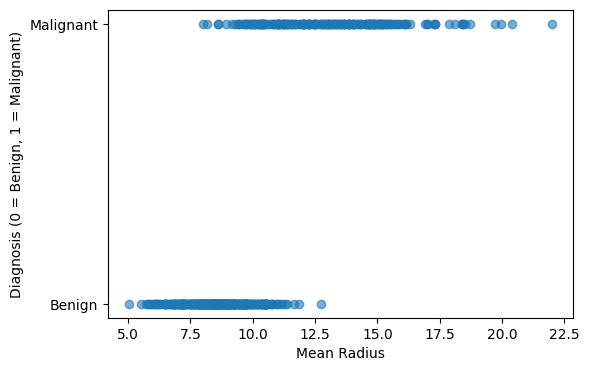

In [35]:
df["diagnosis_num"] = df["Diagnosis"].map({"B": 0, "M": 1})
plt.figure(figsize=(6, 4))
df["radius_mean"] = (df["radius1"] + df["radius2"] + df["radius3"]) / 3

plt.scatter(
    df["radius_mean"],
    df["diagnosis_num"],
    alpha=0.6
)

plt.xlabel("Mean Radius")
plt.ylabel("Diagnosis (0 = Benign, 1 = Malignant)")

# yticks([ticks],[lables]) ticks orig tick labels, new labels
plt.yticks([0, 1], ["Benign", "Malignant"])
plt.grid(False)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Predictions below 0 : 65
Predictions above 1 : 43
Neither valid as probabilities.


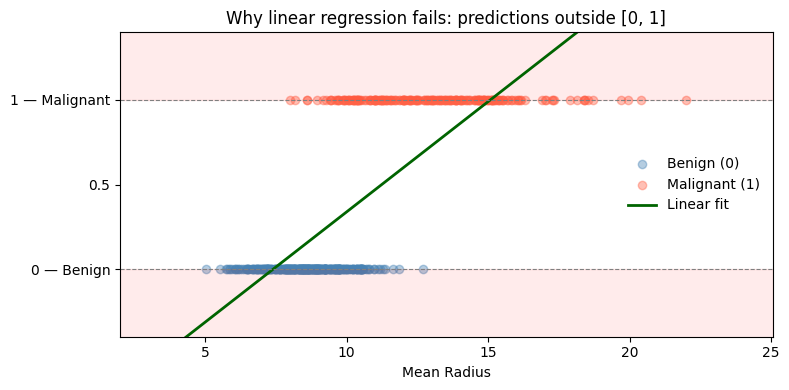

In [36]:
# ── Fit a plain linear regression through the binary labels ──────────────────
from sklearn.linear_model import LinearRegression
import numpy as np

X_rad = df[["radius_mean"]]
y_bin = df["diagnosis_num"]

lin = LinearRegression().fit(X_rad, y_bin)

x_range = np.linspace(df["radius_mean"].min() - 2,
                      df["radius_mean"].max() + 2, 200).reshape(-1, 1)
y_pred  = lin.predict(x_range)

n_below = (lin.predict(X_rad) < 0).sum()
n_above = (lin.predict(X_rad) > 1).sum()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

benign    = df[df["Diagnosis"] == "B"]
malignant = df[df["Diagnosis"] == "M"]

ax.scatter(benign["radius_mean"],    [0]*len(benign),
           alpha=0.4, color="steelblue",  label="Benign (0)")
ax.scatter(malignant["radius_mean"], [1]*len(malignant),
           alpha=0.4, color="tomato",     label="Malignant (1)")

ax.plot(x_range, y_pred, color="darkgreen", linewidth=2, label="Linear fit")

# Shade the invalid probability regions
ax.axhspan(-0.5, 0,  alpha=0.08, color="red")
ax.axhspan(1,   1.5, alpha=0.08, color="red")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axhline(1, color="gray", linewidth=0.8, linestyle="--")

ax.set_xlabel("Mean Radius")
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(["0 — Benign", "0.5", "1 — Malignant"])
ax.set_ylim(-0.4, 1.4)
ax.set_title("Why linear regression fails: predictions outside [0, 1]")
ax.legend(frameon=False)

print(f"Predictions below 0 : {n_below}")
print(f"Predictions above 1 : {n_above}")
print(f"Neither valid as probabilities.")

plt.tight_layout()
plt.show()

Since there are 2 outputs (class or category), we could collapse the output into one axis (in this case `Mean Radius`).

In [37]:
benign = df[df["Diagnosis"] == "B"]
malignant = df[df["Diagnosis"] == "M"]

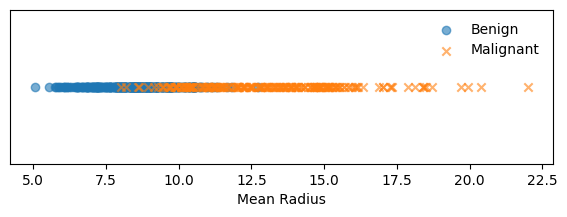

In [38]:
plt.figure(figsize=(7, 2))

plt.scatter(benign["radius_mean"],    [0] * len(benign),    marker='o', alpha=0.6, label="Benign")
plt.scatter(malignant["radius_mean"], [0] * len(malignant), marker='x', alpha=0.6, label="Malignant")

plt.xlabel("Mean Radius")
plt.yticks([])
plt.legend(frameon=False)
plt.grid(False)
plt.show()


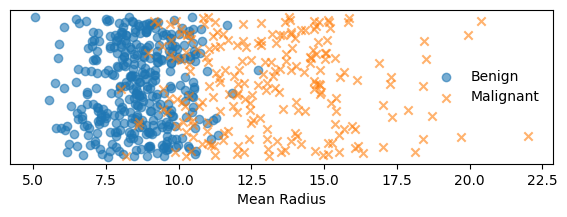

In [39]:
rng = 0.04

plt.figure(figsize=(7, 2))

plt.scatter(
    benign["radius_mean"],
    np.random.uniform(-rng, rng, size=len(benign)),
    marker='o',
    alpha=0.6,
    label="Benign"
)

plt.scatter(
    malignant["radius_mean"],
    np.random.uniform(-rng, rng, size=len(malignant)),
    marker='x',
    alpha=0.6,
    label="Malignant"
)

plt.xlabel("Mean Radius")
plt.yticks([])
plt.legend(frameon=False)
plt.grid(False)

plt.show()

## Other Classification Examples

- Predict categories: Cat vs Dog; Benign vs Malignant
- Outputs can be more than 2 — that is called **multi-class classification**
- Input features can also be more than one (multi-feature classification)

### When the data has more than one feature

With two features (e.g. radius and texture) we can visualise a 2-D scatter
and look for a boundary that separates the classes.


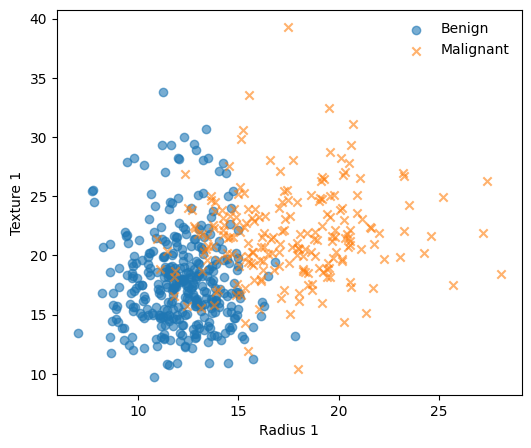

In [40]:
plt.figure(figsize=(6, 5))

plt.scatter(benign["radius1"],    benign["texture1"],    marker='o', alpha=0.6, label="Benign")
plt.scatter(malignant["radius1"], malignant["texture1"], marker='x', alpha=0.6, label="Malignant")

plt.xlabel("Radius 1")
plt.ylabel("Texture 1")
plt.legend(frameon=False)
plt.grid(False)
plt.show()


## Fitting a Logistic Regression Model with Scikit-learn

We use two features — **radius** and **texture** — from the Breast Cancer dataset
and fit `sklearn.linear_model.LogisticRegression` (L-BFGS solver, default settings).


In [41]:
X = df[["radius1", "texture1"]]
y = df["Diagnosis"].map({"B": 0, "M": 1})

print("Features shape:", X.shape)
print("Class counts:")
print(y.value_counts())


Features shape: (569, 2)
Class counts:
Diagnosis
0    357
1    212
Name: count, dtype: int64


## Fit the Model

In [42]:
model = LogisticRegression()   # default: L-BFGS solver, C=1.0 (L2 penalty)
model.fit(X, y)
print("Solver:", model.solver, "  Max iterations:", model.max_iter)


Solver: lbfgs   Max iterations: 100


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


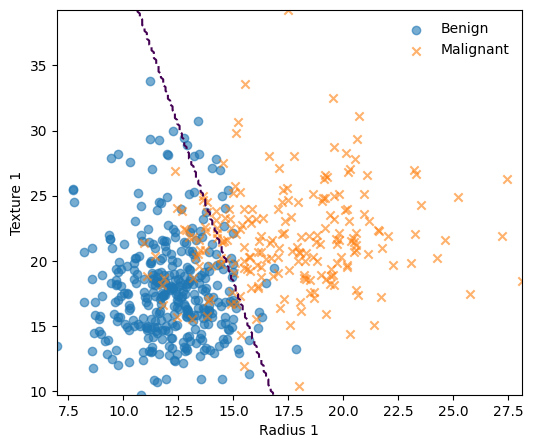

In [43]:
# Decision boundary — predict over a dense grid and contour-plot the class boundary
x_min, x_max = X["radius1"].min(),  X["radius1"].max()
y_min, y_max = X["texture1"].min(), X["texture1"].max()

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contour(xx, yy, Z, levels=[0.5], linestyles='--')

b_plt = df[df["Diagnosis"] == "B"]
m_plt = df[df["Diagnosis"] == "M"]
plt.scatter(b_plt["radius1"], b_plt["texture1"], marker='o', alpha=0.6, label="Benign")
plt.scatter(m_plt["radius1"], m_plt["texture1"], marker='x', alpha=0.6, label="Malignant")

plt.xlabel("Radius 1")
plt.ylabel("Texture 1")
plt.legend(frameon=False)
plt.grid(False)
plt.show()


# Meshgrid explanation

## ☕ Understanding np.meshgrid — Think of a Coffee Shop Floor Plan

Imagine a coffee shop where tables are arranged by:
- **x positions** (distance from left wall): 1, 2, 3  (metres)
- **y positions** (distance from front door): 5, 10, 15  (metres)

We want the coordinates of **every table**.

---

### Step 1 — Start with two 1D arrays
```python
xs = [1, 2, 3]       # left → right (columns)
ys = [5, 10, 15]     # top → bottom (rows)
```

---

### Step 2 — meshgrid fills the floor plan
```python
xx, yy = np.meshgrid(xs, ys)
```

**xx** (how far from the left wall?)
```
1   2   3
1   2   3
1   2   3
```

**yy** (how far from the front door?)
```
5   5   5
10  10  10
15  15  15
```

> 💡 Every table in the same column is the same distance from the left wall → xx repeats across rows.
> Every table in the same row is the same distance from the door → yy repeats down columns.

---

### Step 3 — Read them together = each table's exact location

| Table    | xx[i,j] | yy[i,j] | Location (x, y)  |
|----------|---------|---------|------------------|
| [0, 0]   | 1       | 5       | (1m, 5m)         |
| [0, 2]   | 3       | 5       | (3m, 5m)         |
| [1, 1]   | 2       | 10      | (2m, 10m)        |
| [2, 0]   | 1       | 15      | (1m, 15m)        |

9 tables, all at different locations — no duplicates.

---

### Step 4 — Now connect it to the decision boundary

Instead of tables, think of every grid point as a **hypothetical patient**:
```python
# Every grid point = one hypothetical (radius, texture) combination
points = np.c_[xx.ravel(), yy.ravel()]   # shape: (9, 2)

# Ask the model: benign or malignant at this location?
Z = model.predict(points)

# Put predictions back into grid shape for plotting
Z = Z.reshape(xx.shape)
```

> 🎯 Just like asking "what type of customer sits at each table?",
> we are asking "what diagnosis would the model give at each grid point?"
> The boundary between benign and malignant is where the answer flips.

The steps we have carried out are:

* Look at the data
* find the best boundary that separates the class
* Report how confident we are with the model
* We can also predict the class using the model

In [44]:
new_sample = pd.DataFrame({
    "radius1": [14.2],
    "texture1": [18.5]
})

pred_class = model.predict(new_sample)
pred_prob  = model.predict_proba(new_sample)

print("Predicted class:", "Malignant" if pred_class[0] == 1 else "Benign")
print("Probability [Benign, Malignant]:", pred_prob[0])

Predicted class: Benign
Probability [Benign, Malignant]: [0.69042285 0.30957715]


In [45]:
w1, w2 = model.coef_[0]
b = model.intercept_[0]

print(f"z = {w1:.3f} * radius1 + {w2:.3f} * texture1 + {b:.3f}")

z = 1.046 * radius1 + 0.217 * texture1 + -19.672



**Right now, this feels like magic.
In the rest of this chapter, we’re going to remove the magic.**

# Rest of the Notebook follows Chapter 16

We have hypothetical data of 200 users with
* `Years of Experience or experience`,
* `salary`,
* `paid_account or Not [1, 0]`

You could pack the data as a list like the following:

```[experience, salary, paid_account] ```


If we have a data of users like the one shown above, we could build a model like this

$$ \text{paid_account} = \beta_0 + \beta_1 \text{experience} + \beta_2 \text{salary} + \epsilon $$

In [46]:
tuples = [(0.7,48000,1),(1.9,48000,0),(2.5,60000,1),(4.2,63000,0),
 (6,76000,0),(6.5,69000,0),(7.5,76000,0),(8.1,88000,0),(8.7,83000,1),
  (10,83000,1),(0.8,43000,0),(1.8,60000,0),(10,79000,1),(6.1,76000,0),
   (1.4,50000,0),(9.1,92000,0),(5.8,75000,0),(5.2,69000,0),(1,56000,0),
    (6,67000,0),(4.9,74000,0),(6.4,63000,1),(6.2,82000,0),(3.3,58000,0),
     (9.3,90000,1),(5.5,57000,1),(9.1,102000,0),(2.4,54000,0),
         (8.2,65000,1),(5.3,82000,0),(9.8,107000,0),(1.8,64000,0),
          (0.6,46000,1),(0.8,48000,0),(8.6,84000,1),(0.6,45000,0),
           (0.5,30000,1),(7.3,89000,0),(2.5,48000,1),(5.6,76000,0),
            (7.4,77000,0),(2.7,56000,0),(0.7,48000,0),(1.2,42000,0),
             (0.2,32000,1),(4.7,56000,1),(2.8,44000,1),(7.6,78000,0),
              (1.1,63000,0),(8,79000,1),(2.7,56000,0),(6,52000,1),
               (4.6,56000,0),(2.5,51000,0),(5.7,71000,0),(2.9,65000,0),
                (1.1,33000,1),(3,62000,0),(4,71000,0),(2.4,61000,0),
                 (7.5,75000,0),(9.7,81000,1),(3.2,62000,0),(7.9,88000,0),
                  (4.7,44000,1),(2.5,55000,0),(1.6,41000,0),(6.7,64000,1),
                   (6.9,66000,1),(7.9,78000,1),(8.1,102000,0),(5.3,48000,1),
                    (8.5,66000,1),(0.2,56000,0),(6,69000,0),(7.5,77000,0),
                     (8,86000,0),(4.4,68000,0),(4.9,75000,0),(1.5,60000,0),
                      (2.2,50000,0),(3.4,49000,1),(4.2,70000,0),(7.7,98000,0),(
                          8.2,85000,0),(5.4,88000,0),(0.1,46000,0),(1.5,37000,0),
                           (6.3,86000,0),(3.7,57000,0),(8.4,85000,0),
                            (2,42000,0),(5.8,69000,1),(2.7,64000,0),
                             (3.1,63000,0),(1.9,48000,0),(10,72000,1),
                              (0.2,45000,0),(8.6,95000,0),(1.5,64000,0),
                               (9.8,95000,0),(5.3,65000,0),(7.5,80000,0),
                                (9.9,91000,0),(9.7,50000,1),(2.8,68000,0),
                                 (3.6,58000,0),(3.9,74000,0),(4.4,76000,0),
                                  (2.5,49000,0),(7.2,81000,0),(5.2,60000,1),
                                   (2.4,62000,0),(8.9,94000,0),(2.4,63000,0),
                                    (6.8,69000,1),(6.5,77000,0),(7,86000,0),
                                     (9.4,94000,0),(7.8,72000,1),(0.2,53000,0),
                                      (10,97000,0),(5.5,65000,0),
                                       (7.7,71000,1),(8.1,66000,1),(9.8,91000,0),
                                        (8,84000,0),(2.7,55000,0),(2.8,62000,0),
                                         (9.4,79000,0),(2.5,57000,0),(7.4,70000,1),
                                          (2.1,47000,0),(5.3,62000,1),(6.3,79000,0),(6.8,58000,1),(5.7,80000,0),(2.2,61000,0),(4.8,62000,0),(3.7,64000,0),(4.1,85000,0),(2.3,51000,0),(3.5,58000,0),(0.9,43000,0),(0.9,54000,0),(4.5,74000,0),(6.5,55000,1),(4.1,41000,1),(7.1,73000,0),(1.1,66000,0),(9.1,81000,1),(8,69000,1),(7.3,72000,1),(3.3,50000,0),(3.9,58000,0),(2.6,49000,0),(1.6,78000,0),(0.7,56000,0),(2.1,36000,1),(7.5,90000,0),(4.8,59000,1),(8.9,95000,0),(6.2,72000,0),(6.3,63000,0),(9.1,100000,0),(7.3,61000,1),(5.6,74000,0),(0.5,66000,0),(1.1,59000,0),(5.1,61000,0),(6.2,70000,0),(6.6,56000,1),(6.3,76000,0),(6.5,78000,0),(5.1,59000,0),(9.5,74000,1),(4.5,64000,0),(2,54000,0),(1,52000,0),(4,69000,0),(6.5,76000,0),(3,60000,0),(4.5,63000,0),(7.8,70000,0),(3.9,60000,1),(0.8,51000,0),(4.2,78000,0),(1.1,54000,0),(6.2,60000,0),(2.9,59000,0),(2.1,52000,0),(8.2,87000,0),(4.8,73000,0),(2.2,42000,1),(9.1,98000,0),(6.5,84000,0),(6.9,73000,0),(5.1,72000,0),(9.1,69000,1),(9.8,79000,1),]
data = [list(row) for row in tuples]

xs = [[1.0] + row[:2] for row in data]  # [1, experience, salary]
ys = [row[2] for row in data]           # paid_account

## Logistic (Sigmoid) Function

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

## Its Derivative

$$\sigma'(x) = \sigma(x)\,(1 - \sigma(x))$$

## Why the derivative has this neat form

Starting from the definition:

$$\sigma'(x) = \frac{d}{dx}\left(\frac{1}{1+e^{-x}}\right) = \frac{e^{-x}}{(1+e^{-x})^2}$$

Which can be rewritten as:

$$= \frac{1}{1+e^{-x}} \cdot \frac{e^{-x}}{1+e^{-x}} = \frac{1}{1+e^{-x}} \cdot \left(1 - \frac{1}{1+e^{-x}}\right)$$

$$= \sigma(x)\,(1 - \sigma(x))$$

> 💡 This is why the code computes `y = logistic(x)` first and then returns `y * (1 - y)` —
> it reuses the already-computed sigmoid value instead of recalculating it.

In [47]:
def logistic(x: float) -> float:
    return 1.0 / (1 + math.exp(-x))

def logistic_prime(x: float) -> float:
    y = logistic(x)
    return y * (1 - y)


In [48]:
import math
from scratch.linear_algebra import Vector, dot

In [49]:
xt = list(range(-10, 10))
yt = [logistic(i) for i in xt]


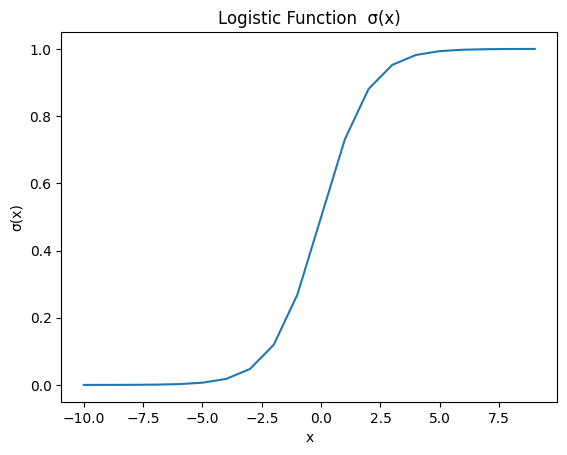

In [50]:
plt.plot(xt, yt)
plt.title("Logistic Function  σ(x)")
plt.xlabel("x")
plt.ylabel("σ(x)")
plt.show()


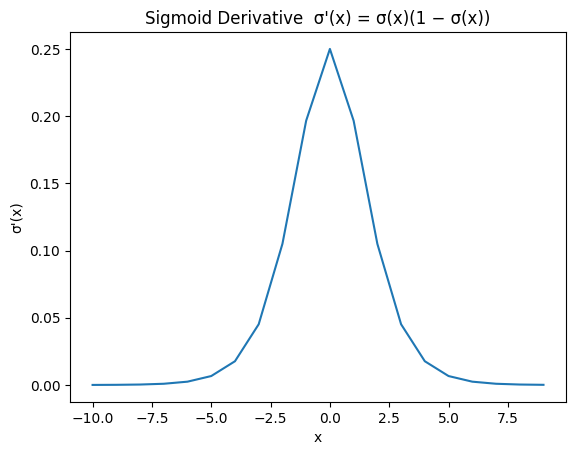

In [51]:
lyt = [logistic_prime(i) for i in xt]
plt.plot(xt, lyt)
plt.title("Sigmoid Derivative  σ'(x) = σ(x)(1 − σ(x))")
plt.xlabel("x")
plt.ylabel("σ'(x)")
plt.show()


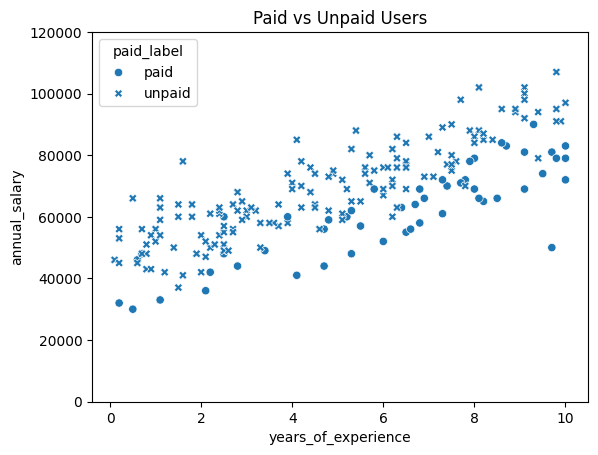

In [52]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame(data)


df = pd.DataFrame(data, columns=["years_of_experience", "annual_salary", "paid"])
df_plot = df.assign(paid_label=df["paid"].map({0: "unpaid", 1: "paid"}))

ax = sns.scatterplot(
    data=df_plot,
    x="years_of_experience",
    y="annual_salary",
    style="paid_label",
    markers={"paid": "o", "unpaid": "X"},
)

ax.set_ylim(0, 120000)   # x-axis limits
# ax.set_xlim(0, 10.5)
plt.title("Paid vs Unpaid Users")
plt.show()

In [53]:
df.paid.value_counts()

,count
paid,
0,148
1,52


## Logistic Regression — Loss Function and Gradient

---

### 1. The Prediction

For a data point $\mathbf{x}$ with weights $\boldsymbol{\beta}$, the predicted probability is:

$$\widehat{y} = \sigma(\mathbf{x} \cdot \boldsymbol{\beta}) = \frac{1}{1 + e^{-\mathbf{x} \cdot \boldsymbol{\beta}}}$$

---

### 2. Negative Log-Likelihood (one point)

We want the model to output high probability when $y=1$ and low when $y=0$.
This is captured by the log-likelihood:

$$\ell(\boldsymbol{\beta}) = \begin{cases} \log \widehat{y} & \text{if } y = 1 \\ \log(1 - \widehat{y}) & \text{if } y = 0 \end{cases}$$


We **negate** the log-likelihood because gradient descent minimizes — and minimizing −log L(β) is equivalent to maximizing log L(β).

$$L(\boldsymbol{\beta}) = -\ell(\boldsymbol{\beta}) = \begin{cases} -\log \widehat{y} & \text{if } y = 1 \\ -\log(1 - \widehat{y}) & \text{if } y = 0 \end{cases}$$

---

### 3. Total Loss (all points)

Sum the per-point losses across the entire dataset:

$${L}(\boldsymbol{\beta}) = \sum_{i=1}^{n} L_i = -\sum_{i=1}^{n} \left[ y_i \log \widehat{y}_i + (1 - y_i)\log(1 - \widehat{y}_i) \right]$$

> 💡 This single formula covers both cases above —
> when $y_i=1$ the second term vanishes, when $y_i=0$ the first term vanishes.

---

### 4. Partial Derivative (one point, one weight $\beta_j$)

Taking the derivative with respect to $\beta_j$:

$$\frac{\partial L}{\partial \beta_j} = -\left(y - \sigma(\mathbf{x} \cdot \boldsymbol{\beta})\right) x_j$$

$$= -\left(y - \widehat{y}\right) x_j$$

> 💡 This is elegant — the gradient is just the **prediction error** $(y - \widehat{y})$
> scaled by the feature value $x_j$. The messy chain rule cancels out cleanly
> because of the sigmoid's nice derivative $\sigma'= \sigma(1-\sigma)$.

---

### 5. Full Gradient (all points, all weights)

The gradient vector across all weights and all data points:

$$\nabla_{\boldsymbol{\beta}}\,{L} = \sum_{i=1}^{n} \nabla_{\boldsymbol{\beta}}\, L_i = -\sum_{i=1}^{n} \left(y_i - \widehat{y}_i\right)\mathbf{x}_i$$

Which in component form is:

$$\left[\nabla_{\boldsymbol{\beta}}\,{L}\right]_j = -\sum_{i=1}^{n} \left(y_i - \widehat{y}_i\right) x_{ij}$$

---

### Code ↔ Math mapping

| Code | Math |
|------|------|
| `logistic(dot(x, beta))` | $\widehat{y} = \sigma(\mathbf{x}^T \boldsymbol{\beta)}$ |
| `_negative_log_likelihood` | $L_i$ (one point) |
| `negative_log_likelihood` | ${L} (\boldsymbol{\beta})$ (all points) |
| `_negative_log_partial_j` | $-\,(y - \widehat{y}),x_j$ |
| `_negative_log_gradient` | $\nabla_{\boldsymbol{\beta}}\,L_i$ (one point) |
| `negative_log_gradient` | $\nabla_{\boldsymbol{\beta}}\,{L}$ (all points) |

In [54]:
def _negative_log_likelihood(x: Vector, y: float, beta: Vector) -> float:
    """The negative log likelihood for one data point"""
    if y == 1:
        return -math.log(logistic(dot(x, beta)))
    else:
        return -math.log(1 - logistic(dot(x, beta)))

from typing import List

def negative_log_likelihood(xs: List[Vector],
                            ys: List[float],
                            beta: Vector) -> float:
    return sum(_negative_log_likelihood(x, y, beta)
               for x, y in zip(xs, ys))

from scratch.linear_algebra import vector_sum

def _negative_log_partial_j(x: Vector, y: float, beta: Vector, j: int) -> float:
    """
    The j-th partial derivative for one data pont
    here i is the index of the data point
    """
    return -(y - logistic(dot(x, beta))) * x[j]

def _negative_log_gradient(x: Vector, y: float, beta: Vector) -> Vector:
    """
    The gradient for one data point
    """
    return [_negative_log_partial_j(x, y, beta, j)
            for j in range(len(beta))]

def negative_log_gradient(xs: List[Vector],
                          ys: List[float],
                          beta: Vector) -> Vector:
    return vector_sum([_negative_log_gradient(x, y, beta)
                       for x, y in zip(xs, ys)])


The following code accomplishes the following:

* rescales the data if the SD > 0 (ignores column 1)

It rescales each column independently to a z-score:
$v[i] \leftarrow \frac{v[i]-\text{mean}_i}{\text{stdev}_i}$



In [55]:
try:
    from scratch.working_with_data import rescale
except AssertionError:
    pass

In [56]:
from scratch.multiple_regression import least_squares_fit, predict
from scratch.gradient_descent import gradient_step

In [57]:
learning_rate = 0.001
rescaled_xs = rescale(xs)
beta = least_squares_fit(rescaled_xs, ys, learning_rate, 1000, 1)
# [0.26, 0.43, -0.43]
print("beta: ", beta)

least squares fit: 100%|██████████| 1000/1000 [00:04<00:00, 247.54it/s]

beta:  [0.2554054269472964, 0.43740462127289914, -0.42710550634623023]


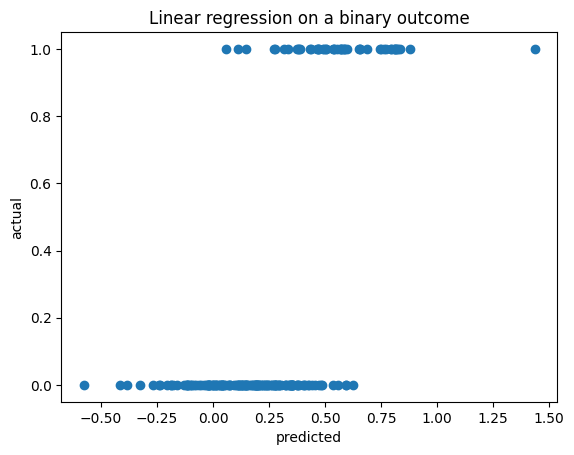

In [58]:
predictions = [predict(x_i, beta) for x_i in rescaled_xs]

plt.scatter(predictions, ys)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("Linear regression on a binary outcome")
plt.show()


## ⚠️ Why Linear Regression Fails for Classification: Two Specific Problems

The scatter plot above (predicted vs actual) makes both problems visible.

### Problem 1: Outputs are not bounded to [0, 1]

We need outputs we can interpret as probabilities. An output of `0.25` means "25% chance of paid account" — that's meaningful. But the linear model produces:
- Large **positive** predictions (e.g. `1.8`) for high-experience users — exceeds 1, not a valid probability
- **Negative** predictions (e.g. `-0.3`) for low-salary users — below 0, not a valid probability

### Problem 2: The coefficient estimates are *biased*

The regression coefficient for experience is `β ≈ 0.43`, so more experience → larger predicted value. But since the true maximum is `1`, very large experience values *force* the model to produce predictions above 1. To compensate, the model assigns very large **negative errors** `ε` to high-experience users.

This means errors **are** correlated with the input features — a core violation of the linear regression assumption. As a result, our estimate of `β` is systematically biased.

### What we actually need

> For large positive `dot(x, β)` → probability close to **1**  
> For large negative `dot(x, β)` → probability close to **0**

This is exactly what the **logistic function** provides.

## Linear Regression vs Logistic Regression — Side-by-Side

| | Linear Regression | Logistic Regression |
|---|---|---|
| **Goal** | Predict a continuous number | Predict a probability (binary outcome) |
| **Output** | Any real number $(-\infty, +\infty)$ | Probability $\in (0,1)$ via sigmoid |
| **Fitting** | Minimise $\sum(\widehat{y}-y)^2$ | Minimise negative log-likelihood |
| **Gradient** | $\sum(\widehat{y}_i - y_i)x_i$ | $\sum(\widehat{y}_i - y_i)x_i$ (same form!) |
| **Examples** | Salary, temperature, house price | Paid/unpaid, disease/no disease |

> 💡 The gradient update has the **same elegant form** in both cases —
> the difference is that $\widehat{y}$ goes through the sigmoid in logistic regression.


## 3. Likelihood vs Log-Likelihood

### Likelihood

If data points are independent, the total likelihood is the product of individual likelihoods:

$$L(\beta) = \prod_{i=1}^n p(y_i \mid x_i, \beta)$$

### Why we use the *log*-likelihood instead

Two practical reasons:

1. **Same maximiser**: `log` is a strictly increasing function, so any `β` that maximises `L(β)` also maximises `log L(β)` — and vice versa. We lose nothing mathematically.

2. **Numerical stability**: `L(β)` is a product of many probabilities, each between 0 and 1. Multiplying hundreds of small numbers together causes **floating-point underflow** (the result rounds to 0). Taking logs turns the product into a sum, which is numerically stable:

$$\ell(\beta) = \log L(\beta) = \sum_i \log p(y_i \mid x_i, \beta)$$

### We actually minimise the *negative* log-likelihood

Since `gradient_descent` minimises things, we work with:

$${L}(\beta) = -\ell(\beta) = -\sum_i \left[ y_i \log f(x_i^\top \beta) + (1-y_i) \log(1 - f(x_i^\top \beta)) \right]$$

Minimising this is identical to maximising the likelihood.

In [59]:
from scratch.machine_learning import train_test_split
import random
import tqdm

random.seed(0)
x_train, x_test, y_train, y_test = train_test_split(rescaled_xs, ys, 0.33)

learning_rate = 0.01

# pick a random starting point
beta = [random.random() for _ in range(3)]

with tqdm.trange(5000) as t:
    for epoch in t:
        gradient = negative_log_gradient(x_train, y_train, beta)
        beta = gradient_step(beta, gradient, -learning_rate)
        loss = negative_log_likelihood(x_train, y_train, beta)
        t.set_description(f"loss: {loss:.3f} beta: {beta}")

loss: 39.963 beta: [-2.023903247625139, 4.693047853942648, -4.469811321910746]: 100%|██████████| 5000/5000 [00:23<00:00, 211.66it/s]


after which we find that beta is approximately:

[-2.0, 4.7,
-4.5]

These are coefficients for the rescaled data, but we can transform them back to the
original data as well:

In [60]:
from scratch.working_with_data import scale

means, stdevs = scale(xs)
beta_unscaled = [(beta[0]
                  - beta[1] * means[1] / stdevs[1]
                  - beta[2] * means[2] / stdevs[2]),
                  beta[1] / stdevs[1],
                  beta[2] / stdevs[2]]
# [8.9, 1.6, -0.000288]

assert (negative_log_likelihood(xs, ys, beta_unscaled) ==
        negative_log_likelihood(rescaled_xs, ys, beta))

Model (after fitting)

$
\widehat{p} = P(\text{paid}=1\mid x)=\sigma(z),$

$\quad z = 8.9 + 1.6\cdot \text{experience} - 2.88\times 10^{-4}\cdot \text{salary}$


What each coefficient means

Logistic regression is linear in log-odds:

$\log\frac{\widehat p}{1-\widehat p} = z$

So:

* Experience (1.6): +1 year adds +1.6 to the log-odds
⇒ odds multiply by e^{1.6}\approx 4.95 (about 5× higher odds per year, holding salary fixed).

* Salary ($-2.88e−4$): +\$1 adds $-2.88\times 10^{-4}$ to log-odds

More interpretable per \$10,000:
$(-2.88\times 10^{-4})\times 10{,}000 = -2.88$
⇒ odds multiply by $e^{-2.88}\approx 0.056$

(about a 94% reduction in odds per $10k, holding experience fixed).

## ⚠️ Important: Coefficient Interpretation is Non-Trivial

Unlike linear regression, you **cannot** say "each extra year of experience increases the probability of a paid account by a fixed amount."

Because the output goes through the **sigmoid**, the *impact* of any coefficient depends on the values of all other inputs:

- If `dot(beta, x_i)` is already very large (probability near 1), increasing it further barely changes the output probability.
- If `dot(beta, x_i)` is near 0 (probability near 0.5), a small change has a large effect.

What we *can* say (all else being equal):
- More **experience** → more likely to be a paid account (`β_exp = +1.6 > 0`)
- Higher **salary** → less likely to be a paid account (`β_sal = -0.000288 < 0`)

The magnitude of those effects is **context-dependent** — it varies across the range of the data.

Let’s plug a data point (x[1] from our data set) directly into the fitted logistic regression and interpret it.

Given

Data point:

	•	Experience = 1.9
	•	Salary = 48,000
	•	Actual outcome y = 0

Coefficients:

* $\beta_0$ = 8.9
* $\beta_{\text{exp}}$ = 1.6
* $\beta_{\text{sal}} = -2.88\times 10^{-4}$





# 1) Compute the linear score z

\begin{aligned}
z
&= 8.9 + 1.6(1.9) - 2.88\times10^{-4}(48{,}000) \\
&= 8.9 + 3.04 - 13.824 \\
&= -1.884
\end{aligned}

⸻

# 2) Convert to probability (sigmoid)

$\widehat p = \sigma(z) = \frac{1}{1+e^{-z}} = \frac{1}{1+e^{1.884}} \approx 0.132$

So the model predicts about a 13.2% chance that this person pays for an account.

⸻

# 3) Compare with the true label
	•	True y = 0
	•	Predicted probability ≈ 0.13

That’s consistent: the model thinks “not paid” is much more likely than “paid”.

⸻

# 4) Interpretation for this point

* The salary term dominates:
-13.8 from salary overwhelms the positive experience effect.
* If salary were lower, the same experience would lead to a much higher probability.
* If experience increased slightly (say to 2.9 years), z would increase by 1.6 and the probability would jump noticeably because z is near the sensitive region of the sigmoid.

# 5) (Optional) Log-odds view

$\log\frac{\widehat p}{1-\widehat p} = -1.884$

So the odds of paying are about 0.15 : 1.

or 0.15, we can write this as 0.15/1 or 0.15:1

Next steps:

	•	Compute the gradient contribution of this point
	•	See how much each feature would need to change to flip the prediction
	•	Visualize where this point lies on the sigmoid curve

In [61]:
true_positives = false_positives = true_negatives = false_negatives = 0

for x_i, y_i in zip(x_test, y_test):
    prediction = logistic(dot(beta, x_i))

    if y_i == 1 and prediction >= 0.5:  # TP: paid and we predict paid
        true_positives += 1
    elif y_i == 1:                      # FN: paid and we predict unpaid
        false_negatives += 1
    elif prediction >= 0.5:             # FP: unpaid and we predict paid
        false_positives += 1
    else:                               # TN: unpaid and we predict unpaid
        true_negatives += 1

precision = true_positives / (true_positives + false_positives)
recall = true_positives / (true_positives + false_negatives)

print(precision, recall)

assert precision == 0.75
assert recall == 0.8

0.75 0.8


This gives a precision of 75% (“when we predict paid account we’re right 75% of the
time”) and a recall of 80% (“when a user has a paid account we predict paid account
80% of the time”), which is not terrible considering how little data we have.

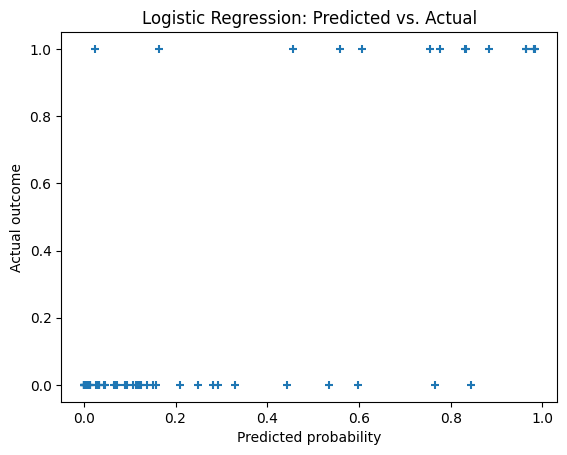

In [62]:
predictions = [logistic(dot(beta, x_i)) for x_i in x_test]
plt.scatter(predictions, y_test, marker='+')
plt.xlabel("Predicted probability")
plt.ylabel("Actual outcome")
plt.title("Logistic Regression: Predicted vs. Actual")
plt.show()


## 🔗 Aside: Correlation ≠ Causation

Before we move to SVMs, a brief reminder relevant to any classification model.

A model that finds a strong association between a feature and an outcome does **not** imply causation. The classic example: ice cream sales and drowning incidents are positively correlated — not because one causes the other, but because both are driven by a third variable (temperature).

Always ask: *Is there a confounding variable that explains the observed correlation?*

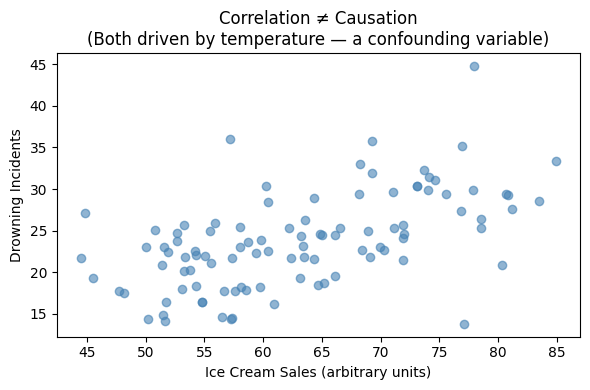

In [63]:
# ── Correlation ≠ Causation: A Cautionary Note ──────────────────────────────
# Ice cream sales and drowning incidents are both higher in summer.
# They are correlated — but ice cream does NOT cause drowning.
# The confounding variable is temperature (hot weather drives both).

import numpy as np

np.random.seed(42)
n = 100
temperature = np.random.uniform(60, 100, n)            # degrees F
ice_cream   = 0.8 * temperature + np.random.normal(0, 5, n)
drowning    = 0.3 * temperature + np.random.normal(0, 4, n)

plt.figure(figsize=(6, 4))
plt.scatter(ice_cream, drowning, alpha=0.6, color='steelblue')
plt.xlabel("Ice Cream Sales (arbitrary units)")
plt.ylabel("Drowning Incidents")
plt.title("Correlation ≠ Causation\n(Both driven by temperature — a confounding variable)")
plt.tight_layout()
plt.show()


## The Decision Boundary

The decision boundary is the set of all points $\mathbf{x}$ where the model is exactly 50/50 — maximum uncertainty.

Recall that the predicted probability is $\hat{p} = \sigma(z)$ where $z = \mathbf{x}^\top\boldsymbol{\beta}$. The sigmoid outputs exactly 0.5 at one place only: when $z = 0$, because:

$$\sigma(0) = \frac{1}{1+e^{0}} = \frac{1}{1+1} = \frac{1}{2}$$

So the boundary is the set of all $\mathbf{x}$ satisfying:

$$\beta_0 + \beta_1 x_1 + \beta_2 x_2 = 0$$

| Region | $z$ | $\hat{p}$ | Prediction |
|---|---|---|---|
| above boundary | $> 0$ | $> 0.5$ | class 1 |
| **on boundary** | $= 0$ | $= 0.5$ | 50/50 |
| below boundary | $< 0$ | $< 0.5$ | class 0 |

With our fitted coefficients $\boldsymbol{\beta} = [8.9,\ 1.6,\ -0.000288]$ this becomes a concrete line in (experience, salary) space:

$$8.9 + 1.6 \cdot \text{experience} - 0.000288 \cdot \text{salary} = 0$$

At 5 years experience the boundary salary is $\approx \$58{,}680$. Points below that salary are predicted paid; above it, unpaid.

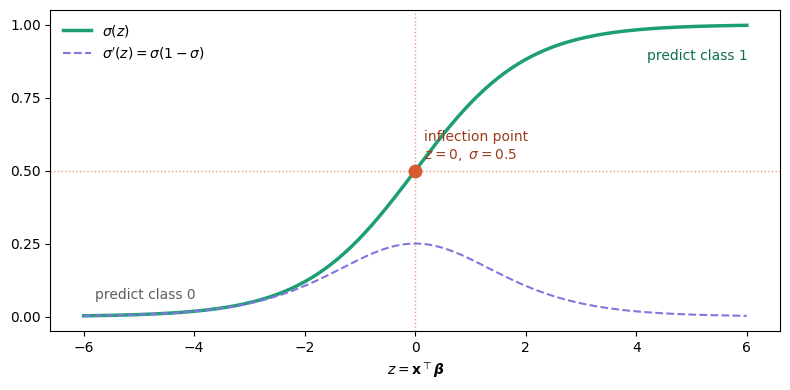

In [64]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-6, 6, 300)
sigma     = 1 / (1 + np.exp(-z))
sigma_prime = sigma * (1 - sigma)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(z, sigma,       color="#1D9E75", linewidth=2.5, label=r"$\sigma(z)$")
ax.plot(z, sigma_prime, color="#7F77DD", linewidth=1.5,
        linestyle="--", label=r"$\sigma'(z) = \sigma(1-\sigma)$")

# inflection point
ax.scatter([0], [0.5], color="#D85A30", zorder=5, s=80)
ax.axvline(0,   color="#D85A30", linewidth=1, linestyle=":", alpha=0.6)
ax.axhline(0.5, color="#D85A30", linewidth=1, linestyle=":", alpha=0.6)
ax.text(0.15, 0.54, "inflection point\n$z=0,\\ \\sigma=0.5$",
        color="#993C1D", fontsize=10)

ax.text( 4.2, 0.88, "predict class 1", color="#0F6E56", fontsize=10)
ax.text(-5.8, 0.06, "predict class 0", color="#5F5E5A", fontsize=10)

ax.set_xlabel("$z = \\mathbf{x}^\\top\\boldsymbol{\\beta}$")
ax.set_ylim(-0.05, 1.05)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.legend(frameon=False)
ax.grid(False)
plt.tight_layout()
plt.show()

Three things to notice on this plot:
The orange dot at (0,0.5) is the inflection point — the only place the curve changes from concave to convex, and exactly where the decision boundary sits.

The dashed purple curve is $σ′(z)=σ(z)(1−σ(z))\sigma'(z)$, the derivative. It peaks at z=0 with a value of
0.25 — meaning the sigmoid is most sensitive to changes in
z right at the boundary. A small push in either direction matters most there. Far from zero the derivative flattens to nearly nothing, which is why coefficient interpretation depends on where you are on the curve.

# Support Vector Machines (SVMs)

The set of points where `dot(beta, x_i) == 0` is the **decision boundary** of our logistic model — a hyperplane that splits the feature space into two half-spaces.


SVMs take a different approach to finding this hyperplane: rather than maximising likelihood, they look for the hyperplane that **best separates** the classes in training data.

## Maximum-Margin Classifier

The SVM finds the hyperplane that **maximises the margin** — the distance to the nearest training point in each class. Those nearest points are called the **support vectors**.

```
          Class A  |  Class B
    ○  ○  ○        |         ×  ×  ×
          ○  ○  [margin]  ×  ×
               ○   |   ×
                   ↑
           decision boundary
           (equidistant from
            nearest points)
```

A wider margin generally means better generalisation to new data.

## Non-Separability

A separating hyperplane may not exist at all. In our "who pays?" dataset, there is **no single line** that perfectly separates paid from unpaid users — the classes overlap.

## The Kernel Trick

When data is not linearly separable in its original space, we can **map it to a higher-dimensional space** where it *is* separable.

**Example:** consider this 1D dataset that is not linearly separable:

```
   ×    ○  ○  ○    ×
  -3   -1  0  1   3
```

Map each point `x` to `(x, x²)`. In 2D, the positives form a cluster near the origin and the negatives are far out — now a horizontal line separates them perfectly.

| x (original) | x² (new dimension) | φ(x) = (x, x²) | x² > 1.5? | class |
|:---:|:---:|:---:|:---:|:---:|
| −3   | 9    | (−3, 9)      | ✓ yes | × negative |
| −2.5 | 6.25 | (−2.5, 6.25) | ✓ yes | × negative |
| −1   | 1    | (−1, 1)      | ✗ no  | ○ positive |
| 0    | 0    | (0, 0)       | ✗ no  | ○ positive |
| 1    | 1    | (1, 1)       | ✗ no  | ○ positive |
| 2.5  | 6.25 | (2.5, 6.25)  | ✓ yes | × negative |
| 3    | 9    | (3, 9)       | ✓ yes | × negative |


**The kernel trick**: rather than computing the explicit mapping (which could be very expensive), a **kernel function** `K(x, z)` computes the dot product *in the higher-dimensional space directly*. Common kernels:
- Linear: `K(x, z) = x·z`
- Polynomial: `K(x, z) = (x·z + c)^d`
- RBF (Gaussian): `K(x, z) = exp(−γ‖x−z‖²)`

In practice, use a well-tested library (scikit-learn `SVC`) rather than implementing SVMs from scratch — the optimisation involves quadratic programming that requires specialised solvers.

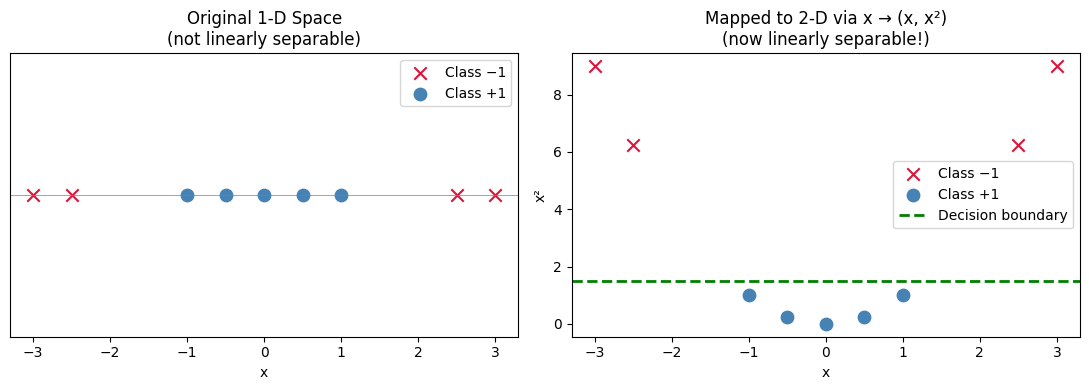

The dashed line (x² = 1.5) perfectly separates the two classes.


In [65]:
# ── SVM demo: kernel trick visualised ───────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# 1-D non-separable data
x_neg = np.array([-3.0, -2.5, 2.5, 3.0])
x_pos = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: original 1-D space — not separable
ax = axes[0]
ax.scatter(x_neg, np.zeros_like(x_neg), marker='x', s=80, color='crimson',  label='Class −1')
ax.scatter(x_pos, np.zeros_like(x_pos), marker='o', s=80, color='steelblue', label='Class +1')
ax.set_yticks([])
ax.set_xlabel("x")
ax.set_title("Original 1-D Space\n(not linearly separable)")
ax.legend()
ax.axhline(0, color='gray', linewidth=0.5)

# Right: mapped to 2-D with x → (x, x²)
ax2 = axes[1]
ax2.scatter(x_neg, x_neg**2, marker='x', s=80, color='crimson',  label='Class −1')
ax2.scatter(x_pos, x_pos**2, marker='o', s=80, color='steelblue', label='Class +1')
ax2.axhline(1.5, color='green', linestyle='--', linewidth=2, label='Decision boundary')
ax2.set_xlabel("x")
ax2.set_ylabel("x²")
ax2.set_title("Mapped to 2-D via x → (x, x²)\n(now linearly separable!)")
ax2.legend()

plt.tight_layout()
plt.show()
print("The dashed line (x² = 1.5) perfectly separates the two classes.")


In [66]:
# ── Practical SVM with scikit-learn ──────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Generate a small synthetic dataset
X_demo, y_demo = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                      n_informative=2, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_demo, y_demo, test_size=0.3, random_state=0)

# Linear SVM
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_tr, y_tr)

# RBF (Gaussian) kernel SVM
svm_rbf = SVC(kernel='rbf', gamma='scale')
svm_rbf.fit(X_tr, y_tr)

print("=== Linear SVM ===")
print(classification_report(y_te, svm_linear.predict(X_te)))

print("=== RBF SVM ===")
print(classification_report(y_te, svm_rbf.predict(X_te)))


=== Linear SVM ===
              precision    recall  f1-score   support

           0       0.91      0.84      0.87        37
           1       0.77      0.87      0.82        23

    accuracy                           0.85        60
   macro avg       0.84      0.85      0.84        60
weighted avg       0.86      0.85      0.85        60

=== RBF SVM ===
              precision    recall  f1-score   support

           0       0.92      0.89      0.90        37
           1       0.83      0.87      0.85        23

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60

